# ML Zoomcamp 2026 - Homework 2
Machine Learning for Regression (pinned 2026 car fuel efficiency release)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data preparation

In [3]:
!wget -q -nc https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = pd.read_csv('car_fuel_efficiency_2026.csv')[cols]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA: does `fuel_efficiency_mpg` have a long tail?

0.08080419601878173

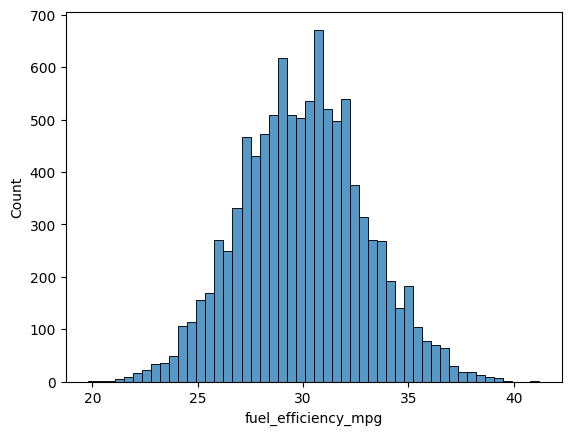

In [4]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)
df.fuel_efficiency_mpg.skew()  # ~0.08 -> roughly symmetric, NO long tail (no log transform needed)

## Q1. Missing values

In [5]:
df.isnull().sum()  # horsepower: 877 -> answer: 'horsepower'

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2. Median for horsepower

In [6]:
df.horsepower.median()  # 254.0

254.0

## Split + training functions

In [7]:
def split(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X) + r * np.eye(X.shape[1])
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())


base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def prepare_X(d, fill_value):
    return d[base].fillna(fill_value).values

## Q3. Filling NAs: 0 vs mean

In [8]:
df_train, df_val, df_test = split(df, 42)
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

# fill with 0
w0, w = train_linear_regression(prepare_X(df_train, 0), y_train)
rmse_zero = rmse(y_val, prepare_X(df_val, 0).dot(w) + w0)

# fill with mean computed on TRAIN only
hp_mean = df_train.horsepower.mean()
w0, w = train_linear_regression(prepare_X(df_train, hp_mean), y_train)
rmse_mean = rmse(y_val, prepare_X(df_val, hp_mean).dot(w) + w0)

round(rmse_zero, 3), round(rmse_mean, 3)  # (2.205, 2.202) -> mean is better

(2.205, 2.202)

## Q4. Best regularization parameter

In [9]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    score = rmse(y_val, X_val.dot(w) + w0)
    print(r, round(score, 4))

# 0     -> 2.2053  <-- best
# 0.01  -> 2.2058
# 0.1   -> 2.2241
# 1     -> 2.3492
# 5     -> 2.4094
# 10    -> 2.4195
# 100   -> 2.4292

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


## Q5. RMSE standard deviation across seeds

In [10]:
scores = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    d_train, d_val, d_test = split(df, seed)
    w0, w = train_linear_regression(prepare_X(d_train, 0), d_train.fuel_efficiency_mpg.values)
    score = rmse(d_val.fuel_efficiency_mpg.values, prepare_X(d_val, 0).dot(w) + w0)
    scores.append(score)

print([round(s, 4) for s in scores])
round(np.std(scores), 3)  # 0.029

[2.2392, 2.2021, 2.1634, 2.2044, 2.2019, 2.2458, 2.2697, 2.1908, 2.2166, 2.207]


0.029

## Q6. Evaluation on the test set

In [11]:
d_train, d_val, d_test = split(df, 9)
df_full_train = pd.concat([d_train, d_val])
y_full_train = df_full_train.fuel_efficiency_mpg.values

w0, w = train_linear_regression_reg(prepare_X(df_full_train, 0), y_full_train, r=0.001)
rmse(d_test.fuel_efficiency_mpg.values, prepare_X(d_test, 0).dot(w) + w0)  # 2.2358 -> 2.236

2.235827747191731

## Answers
| Q | Question | Answer |
|---|---|---|
| EDA | Long tail? | No - skew ~0.08, nearly symmetric |
| 1 | Column with missing values | `horsepower` (877) |
| 2 | Median horsepower | 254 |
| 3 | Filling NAs | With mean (2.202 vs 2.205) |
| 4 | Best regularization `r` | 0 |
| 5 | Std of RMSE across seeds | 0.029 |
| 6 | RMSE on test (seed 9, r=0.001) | 2.236 |